In [19]:
import random
import matplotlib.pyplot as plt

In [20]:
# Player 1
states = ["R", "P", "S"]

p1_transition_matrix = {
    "R": {"R": 0.1, "P": 0.5, "S": 0.4},
    "P": {"R": 0.4, "P": 0.1, "S": 0.5},
    "S": {"R": 0.5, "P": 0.4, "S": 0.1},
}

In [21]:
# Player 2
count_moves_matrix = {
    "R": {"R": 1, "P": 1, "S": 1},
    "P": {"R": 1, "P": 1, "S": 1},
    "S": {"R": 1, "P": 1, "S": 1}
}

In [22]:
#Player 2 methods to predict and learn
def learn(prev, now):
    count_moves_matrix[prev][now] += 1

def get_probability(prev):
    row = count_moves_matrix[prev]
    total_moves = sum(list(row.values()))
    return {"R": round(row["R"] / total_moves, 2),
            "P": round(row["P"] / total_moves, 2),
            "S": round(row["S"] / total_moves, 2)
            }

def counter_attack(prev):
    probability = get_probability(prev)
    predicted_move = max(probability, key=probability.get)
    if predicted_move == "R":
        return "P"
    elif predicted_move == "P":
        return "S"
    else:
        return "R"


In [23]:
#Game logic
def compare_moves(p1, p2):
    if p1 == p2:
        return 0
    if (p1 == "R" and p2 == "S") or (p1 == "P" and p2 == "R") or (p1 == "S" and p2 == "P"):
        return 1
    else:
        return -1


In [24]:
#Method to print Player 2 transition matrix from count_moves_matrix
def get_transition_matrix(count_matrix):
    return {
        "R": get_probability("R"),
        "P": get_probability("P"),
        "S": get_probability("S")
    }

In [28]:
#Game simulation
score = 0
scores = []

p1_current_move = random.choice(states)

p2_current_move = random.choice(states)

score += compare_moves(p1_current_move, p2_current_move)
scores.append(score)

for _ in range(1000):
    p1_next_move = random.choices(population=list(p1_transition_matrix[p1_current_move].keys()),
                                  weights=list(p1_transition_matrix[p1_current_move].values()))[0]

    p2_next_move = counter_attack(p1_current_move)

    score += compare_moves(p1_next_move, p2_next_move)
    scores.append(score)

    learn(p1_current_move, p1_next_move)

    p1_current_move = p1_next_move


In [32]:
#Comparing matrices and final score
print("Actual Player 1 transition matrix:")
for move, prediction in p1_transition_matrix.items():
    print(move, ": ", prediction)

print("Learned transition matrix:")
for move, prediction in get_transition_matrix(count_moves_matrix).items():
    print(move, ": ", prediction)

print("Final score:", score)

Actual Player 1 transition matrix:
R :  {'R': 0.1, 'P': 0.5, 'S': 0.4}
P :  {'R': 0.4, 'P': 0.1, 'S': 0.5}
S :  {'R': 0.5, 'P': 0.4, 'S': 0.1}
Learned transition matrix:
R :  {'R': 0.09, 'P': 0.49, 'S': 0.42}
P :  {'R': 0.43, 'P': 0.08, 'S': 0.48}
S :  {'R': 0.48, 'P': 0.42, 'S': 0.11}
Final score: -237


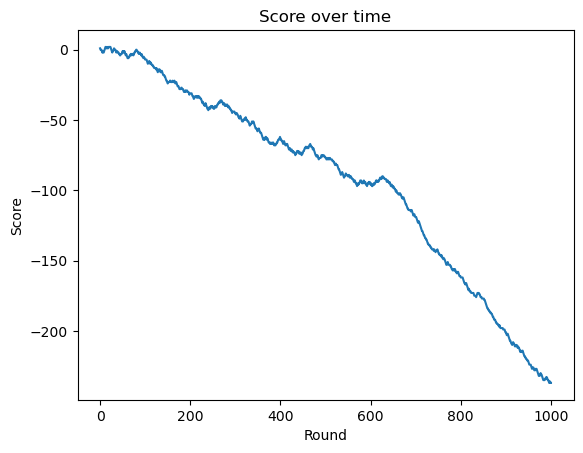

In [33]:
plt.plot(scores)
plt.xlabel("Round")
plt.ylabel("Score")
plt.title("Score over time")
plt.show()